<a href="https://colab.research.google.com/github/alscop/ESAA-26-1/blob/main/ESAA_OB_week12_2%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> 딥러닝 파이토치 교과서 9장 p.506-518, 13장 p.682~708


# 9장 자연어 전처리

## 9.1 자연어 처리란

인간 언어에 대한 이해도 필요  

언어종류, 형태 등  

<완성도 높은 자연어 처리>
- 스팸 처리
- 맞춤법 검사
- 단어 검색
- 객체 인식

<완성도 낮은 자연어 처리>
- 질의응답
- 요약
- 유사 단어 바꾸어 쓰기
- 대화

### 9.1.1 자연어 처리 용어 및 과정

- 말뭉치 코퍼스 Corpus  
- 토큰 : 문서 나누는 단위
- 토큰화 : 텍스트를 문장이나 단어로 분리하는 것  
- 불용어: 분석과 관계 없으며 문장 내에서 많이 등장하는 단어
- 어간 추출: 단어를 기본 형태로 변환
- 품사 태깅: 문장에서 품사 식별을 위해 붙이는 태그



In [1]:
# 9-1 문장 토큰화
!pip install nltk

In [2]:
# 9-1 문장 토큰화
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
# 9-2 품사 태깅에 필요한 자원 내받기
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...


['Is', 'it', 'possible', 'distinguishing', 'cats', 'and', 'dogs']


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [4]:
# 9-3 품사 태깅
tagged_text = nltk.pos_tag(text)
print(tagged_text)

[('Is', 'VBZ'), ('it', 'PRP'), ('possible', 'JJ'), ('distinguishing', 'VBG'), ('cats', 'NNS'), ('and', 'CC'), ('dogs', 'NNS')]


In [5]:
# 9-4 nltk 라이브러리 호출 및 문장 정의
import nltk
nltk.download('punkt')
string1 = "my favorite subject is math"
string2 = "my favorite subject is math, english, economic, computer science"
nltk.word_tokenize(string1)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['my', 'favorite', 'subject', 'is', 'math']

In [6]:
# 9-5 단어 단위 분리
nltk.word_tokenize(string2)

['my',
 'favorite',
 'subject',
 'is',
 'math',
 ',',
 'english',
 ',',
 'economic',
 ',',
 'computer',
 'science']

In [7]:
# KoNLPy 설치
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 34.0 MB/s eta 0:00:00


In [8]:
# 9-6 라이브러리 호출 및 문장 형태소 변환
from konlpy.tag import Komoran

# Komoran 형태소 분석기 객체 생성
komoran = Komoran()

# 문장을 형태소 단위로 분석
print(komoran.morphs('딥러닝이 쉽나요? 어렵나요?'))

['딥러닝이', '쉽', '나요', '?', '어렵', '나요', '?']


In [9]:
# 9-7 품사 태깅
print(komoran.pos('소파 위에 있는 것이 고양이인가요? 강아지인가요?'))

[('소파', 'NNP'), ('위', 'NNG'), ('에', 'JKB'), ('있', 'VV'), ('는', 'ETM'), ('것', 'NNB'), ('이', 'JKS'), ('고양이', 'NNG'), ('이', 'VCP'), ('ㄴ가요', 'EF'), ('?', 'SF'), ('강아지', 'NNG'), ('이', 'VCP'), ('ㄴ가요', 'EF'), ('?', 'SF')]


# 13

In [10]:
# 13-1 라이브러리 호출
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pylab as plt

import torchvision.datasets as datasets
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
# 13-2 MNIST 데이터 내려받고 전처리

# MNIST 이미지를 PyTorch 텐서 형태로 변환함
transform = transforms.Compose([transforms.ToTensor()])

# 학습용 MNIST 데이터셋 다운로드 및 전처리함
train_dataset = datasets.MNIST(
    root="../chap13/data",
    train=True,
    transform=transform,
    download=True
)

# 테스트용 MNIST 데이터셋 다운로드 및 전처리함
test_dataset = datasets.MNIST(
    root="../chap13/data",
    train=False,
    transform=transform,
    download=True
)

# 학습용 데이터로더 생성함
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=False
)

# 테스트용 데이터로더 생성함
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.34MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 153kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.54MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [12]:
# 13-3 신경망 생성

# 인코더 네트워크 생성함
class Encoder(nn.Module):
    def __init__(self, encoded_space_dim, fc2_input_dim):
        super().__init__()

        # 합성곱 신경망을 이용하여 이미지의 특징을 추출함
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.ReLU(True),

            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),

            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True)
        )

        # 다차원 이미지 특징맵을 일렬로 펼침
        self.flatten = nn.Flatten(start_dim=1)

        # 펼쳐진 특징을 저차원 잠재 공간으로 압축함
        self.encoder_lin = nn.Sequential(
            nn.Linear(3 * 3 * 32, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )

    def forward(self, x):
        # 이미지에서 특징 추출함
        x = self.encoder_cnn(x)

        # 특징맵을 벡터로 변환함
        x = self.flatten(x)

        # 저차원 잠재 공간으로 압축함
        x = self.encoder_lin(x)

        return x

# 디코더 네트워크 생성함
class Decoder(nn.Module):
    def __init__(self, encoded_space_dim, fc2_input_dim):
        super().__init__()

        # 인코더가 만든 압축 벡터를 다시 큰 벡터로 확장함
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 3 * 3 * 32),
            nn.ReLU(True)
        )

        # 일렬로 펼쳐진 벡터를 다시 이미지 형태의 특징맵으로 변환함
        self.unflatten = nn.Unflatten(
            dim=1,
            unflattened_size=(32, 3, 3)
        )

        # 전치 합성곱을 이용하여 원래 이미지 크기에 가깝게 복원함
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(
                32, 16, 3,
                stride=2,
                output_padding=0
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                16, 8, 3,
                stride=2,
                padding=1,
                output_padding=1
            ),
            nn.BatchNorm2d(8),
            nn.ReLU(True),

            nn.ConvTranspose2d(
                8, 1, 3,
                stride=2,
                padding=1,
                output_padding=1
            )
        )

    def forward(self, x):
        # 압축 벡터를 확장함
        x = self.decoder_lin(x)

        # 벡터를 이미지 특징맵 형태로 변환함
        x = self.unflatten(x)

        # 전치 합성곱으로 이미지 복원함
        x = self.decoder_conv(x)

        # 픽셀값을 0과 1 사이로 맞춤
        x = torch.sigmoid(x)

        return x

In [13]:
# 13-4 손실 함수와 옵티마이저 지정

# 인코더와 디코더 객체 생성함
encoder = Encoder(encoded_space_dim=4, fc2_input_dim=128)
decoder = Decoder(encoded_space_dim=4, fc2_input_dim=128)

# 인코더와 디코더를 CPU 또는 GPU 장치로 이동함
encoder.to(device)
decoder.to(device)

# 최적화할 파라미터 지정함
params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]

# Adam 옵티마이저 지정함
optim = torch.optim.Adam(
    params_to_optimize,
    lr=0.001,
    weight_decay=1e-05
)

# 손실 함수 지정함
loss_fn = torch.nn.MSELoss()

In [14]:
# 13-5 모델 학습 함수 생성

# 한 epoch 동안 모델을 학습하는 함수 정의함
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer, noise_factor=0.3):
    # 인코더를 학습 모드로 설정함
    encoder.train()

    # 디코더를 학습 모드로 설정함
    decoder.train()

    # 배치별 손실값을 저장할 리스트 생성함
    train_loss = []

    # 데이터로더에서 이미지 배치를 하나씩 가져옴
    for image_batch, _ in dataloader:
        # 입력 이미지에 노이즈 추가함
        image_noisy = add_noise(image_batch, noise_factor)

        # 노이즈가 추가된 이미지를 CPU 또는 GPU 장치로 이동함
        image_noisy = image_noisy.to(device)

        # 노이즈 이미지를 인코더에 넣어 압축 표현 생성함
        encoded_data = encoder(image_noisy)

        # 압축 표현을 디코더에 넣어 이미지 복원함
        decoded_data = decoder(encoded_data)

        # 복원 이미지와 노이즈 이미지 사이의 손실 계산함
        loss = loss_fn(decoded_data, image_noisy)

        # 이전 gradient 초기화함
        optimizer.zero_grad()

        # 역전파 수행함
        loss.backward()

        # 파라미터 업데이트함
        optimizer.step()

        # 현재 배치의 손실값 저장함
        train_loss.append(loss.detach().cpu().numpy())

    # 한 epoch의 평균 손실 반환함
    return np.mean(train_loss)

In [15]:
# 13-6 모델 테스트 함수 생성

# 모델의 테스트 손실을 계산하는 함수 정의함
def test_epoch(encoder, decoder, device, dataloader, loss_fn, noise_factor=0.3):
    # 인코더를 평가 모드로 설정함
    encoder.eval()

    # 디코더를 평가 모드로 설정함
    decoder.eval()

    # gradient 계산을 하지 않도록 설정함
    with torch.no_grad():
        # 복원된 이미지를 저장할 리스트 생성함
        conc_out = []

        # 원본 이미지를 저장할 리스트 생성함
        conc_label = []

        # 데이터로더에서 이미지 배치를 하나씩 가져옴
        for image_batch, _ in dataloader:
            # 이미지를 CPU 또는 GPU 장치로 이동함
            image_batch = image_batch.to(device)

            # 이미지를 인코더에 넣어 압축 표현 생성함
            encoded_data = encoder(image_batch)

            # 압축 표현을 디코더에 넣어 이미지 복원함
            decoded_data = decoder(encoded_data)

            # 복원 이미지를 CPU로 이동하여 리스트에 저장함
            conc_out.append(decoded_data.cpu())

            # 원본 이미지를 CPU로 이동하여 리스트에 저장함
            conc_label.append(image_batch.cpu())

        # 리스트에 저장된 모든 복원 이미지를 하나의 텐서로 합침
        conc_out = torch.cat(conc_out)

        # 리스트에 저장된 모든 원본 이미지를 하나의 텐서로 합침
        conc_label = torch.cat(conc_label)

        # 복원 이미지와 원본 이미지 사이의 손실 계산함
        val_loss = loss_fn(conc_out, conc_label)

    # 테스트 손실 반환함
    return val_loss.data

In [16]:
# 13-7 노이즈 데이터 생성

def add_noise(inputs, noise_factor=0.3):
    # 입력 이미지와 같은 크기의 랜덤 노이즈를 생성한 뒤 원본 이미지에 더함
    noisy = inputs + torch.randn_like(inputs) * noise_factor

    # 픽셀값이 0보다 작거나 1보다 커지지 않도록 0~1 범위로 제한함
    noisy = torch.clip(noisy, 0., 1.)

    # 노이즈가 추가된 이미지 반환
    return noisy

In [17]:
# 13-8 한글 깨짐 문제 해결

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔 폰트 설치
!apt-get -qq install fonts-nanum

# 폰트 캐시 갱신
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

# matplotlib 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

Selecting previously unselected package fonts-nanum.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [18]:
# 13-9 이미지 시각화

import matplotlib.pyplot as plt
import torch

def plot_ae_outputs(encoder, decoder, n=5, noise_factor=0.3):
    plt.figure(figsize=(10, 4.5))

    for i in range(n):
        # 첫 번째 행: 원래 이미지
        ax = plt.subplot(3, n, i + 1)

        # 테스트 데이터셋에서 i번째 이미지 가져옴
        img = test_dataset[i][0].unsqueeze(0)

        # 원본 이미지에 노이즈 추가함
        image_noisy = add_noise(img, noise_factor)

        # 노이즈 이미지를 CPU 또는 GPU 장치로 이동함
        image_noisy = image_noisy.to(device)

        # 인코더와 디코더를 평가 모드로 설정함
        encoder.eval()
        decoder.eval()

        # gradient 계산 없이 이미지 복원함
        with torch.no_grad():
            rec_img = decoder(encoder(image_noisy))

        # 원래 이미지 출력
        plt.imshow(img.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        if i == n // 2:
            ax.set_title('원래 이미지')

        # 두 번째 행: 노이즈가 적용된 이미지
        ax = plt.subplot(3, n, i + 1 + n)

        plt.imshow(image_noisy.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        if i == n // 2:
            ax.set_title('노이즈가 적용되어 손상된 이미지')

        # 세 번째 행: 재구성된 이미지
        ax = plt.subplot(3, n, i + 1 + n + n)

        plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        if i == n // 2:
            ax.set_title('재구성된 이미지')

    # subplot 간격 조정
    plt.subplots_adjust(
        left=0.1,
        bottom=0.1,
        right=0.7,
        top=0.9,
        wspace=0.3,
        hspace=0.3
    )

    plt.show()

EPOCH 1/30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



 EPOCH 1/30 	 train loss 0.084 	 val loss 0.055
EPOCH 2/30

 EPOCH 2/30 	 train loss 0.056 	 val loss 0.045
EPOCH 3/30

 EPOCH 3/30 	 train loss 0.053 	 val loss 0.043
EPOCH 4/30

 EPOCH 4/30 	 train loss 0.052 	 val loss 0.042
EPOCH 5/30

 EPOCH 5/30 	 train loss 0.052 	 val loss 0.041
EPOCH 6/30

 EPOCH 6/30 	 train loss 0.051 	 val loss 0.041
EPOCH 7/30

 EPOCH 7/30 	 train loss 0.051 	 val loss 0.040
EPOCH 8/30

 EPOCH 8/30 	 train loss 0.051 	 val loss 0.040
EPOCH 9/30

 EPOCH 9/30 	 train loss 0.051 	 val loss 0.040
EPOCH 10/30

 EPOCH 10/30 	 train loss 0.051 	 val loss 0.039
EPOCH 11/30

 EPOCH 11/30 	 train loss 0.050 	 val loss 0.039
EPOCH 12/30

 EPOCH 12/30 	 train loss 0.050 	 val loss 0.039
EPOCH 13/30

 EPOCH 13/30 	 train loss 0.050 	 val loss 0.039
EPOCH 14/30

 EPOCH 14/30 	 train loss 0.050 	 val loss 0.039
EPOCH 15/30

 EPOCH 15/30 	 train loss 0.050 	 val loss 0.039
EPOCH 16/30

 EPOCH 16/30 	 train loss 0.050 	 val loss 0.039
EPOCH 17/30

 EPOCH 17/30 	 train los

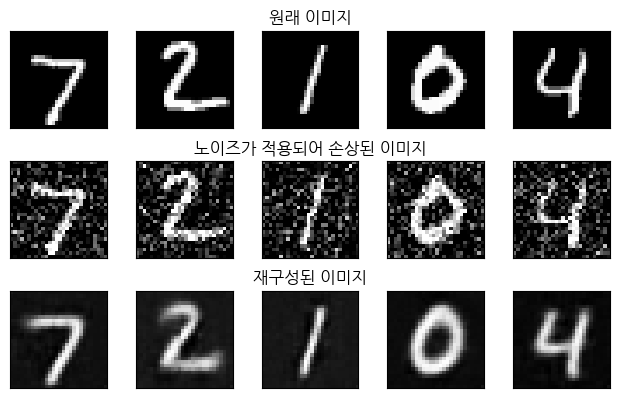

In [19]:
# 13-10 모델 학습

import numpy as np

num_epochs = 30

history_da = {
    'train_loss': [],
    'val_loss': []
}

loss_fn = torch.nn.MSELoss()

for epoch in range(num_epochs):
    print('EPOCH %d/%d' % (epoch + 1, num_epochs))

    # 모델 학습
    train_loss = train_epoch(
        encoder=encoder,
        decoder=decoder,
        device=device,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optim,
        noise_factor=0.3
    )

    # 모델 검증
    val_loss = test_epoch(
        encoder=encoder,
        decoder=decoder,
        device=device,
        dataloader=test_loader,
        loss_fn=loss_fn,
        noise_factor=0.3
    )

    # 학습 손실과 검증 손실 저장
    history_da['train_loss'].append(train_loss)
    history_da['val_loss'].append(val_loss)

    # 현재 epoch 결과 출력
    print(
        '\n EPOCH {}/{} \t train loss {:.3f} \t val loss {:.3f}'.format(
            epoch + 1,
            num_epochs,
            train_loss,
            val_loss
        )
    )

# 학습 후 이미지 시각화
plot_ae_outputs(
    encoder,
    decoder,
    noise_factor=0.3
)

### 13.2.2 변형 오토인코더

In [20]:
!pip install tensorboardX

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 1.0 MB/s eta 0:00:00


In [21]:
# 13-11 필요한 라이브러리 호출

import datetime
import os

from tensorboardX import SummaryWriter

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import matplotlib.pylab as plt

import torchvision.datasets as datasets
import torchvision.transforms as transforms

# CPU 또는 GPU 장치 지정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("사용 장치:", device)

사용 장치: cpu


In [22]:
# 13-12 데이터셋을 내려받은 후 텐서 변환

# MNIST 이미지를 PyTorch 텐서 형태로 변환
transform = transforms.Compose([
    transforms.ToTensor()
])

# 학습용 MNIST 데이터셋 다운로드 및 텐서 변환
train_dataset = datasets.MNIST(
    root="../chap13/data",
    train=True,
    transform=transform,
    download=True
)

# 테스트용 MNIST 데이터셋 다운로드 및 텐서 변환
test_dataset = datasets.MNIST(
    root="../chap13/data",
    train=False,
    transform=transform,
    download=True
)

# 학습용 데이터로더 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=100,
    shuffle=True,
    num_workers=4,
    pin_memory=False
)

# 테스트용 데이터로더 생성
test_loader = DataLoader(
    test_dataset,
    batch_size=100,
    shuffle=False,
    num_workers=4
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [23]:
# 13-13 인코더 네트워크 생성

class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()

        # 입력 데이터를 은닉층으로 변환
        self.input1 = nn.Linear(input_dim, hidden_dim)

        # 은닉층을 다시 은닉층으로 변환
        self.input2 = nn.Linear(hidden_dim, hidden_dim)

        # 잠재공간의 평균값 생성
        self.mean = nn.Linear(hidden_dim, latent_dim)

        # 잠재공간의 로그 분산값 생성
        self.var = nn.Linear(hidden_dim, latent_dim)

        # 활성화 함수 지정
        self.LeakyReLU = nn.LeakyReLU(0.2)

        # 학습 상태 지정
        self.training = True

    def forward(self, x):
        # 입력 데이터를 첫 번째 은닉층에 통과시킴
        h_ = self.LeakyReLU(self.input1(x))

        # 두 번째 은닉층에 통과시킴
        h_ = self.LeakyReLU(self.input2(h_))

        # 평균 계산
        mean = self.mean(h_)

        # 로그 분산 계산
        log_var = self.var(h_)

        # 인코더 네트워크에서 평균과 로그 분산 반환
        return mean, log_var

In [24]:
# 13-14 디코더 네트워크 생성

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()

        # 잠재공간 벡터를 은닉층으로 변환
        self.hidden1 = nn.Linear(latent_dim, hidden_dim)

        # 은닉층을 다시 은닉층으로 변환
        self.hidden2 = nn.Linear(hidden_dim, hidden_dim)

        # 은닉층을 출력 차원으로 변환
        self.output = nn.Linear(hidden_dim, output_dim)

        # 활성화 함수 지정
        self.LeakyReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        # 잠재공간 벡터를 첫 번째 은닉층에 통과시킴
        h = self.LeakyReLU(self.hidden1(x))

        # 두 번째 은닉층에 통과시킴
        h = self.LeakyReLU(self.hidden2(h))

        # 출력층 통과 후 sigmoid 적용
        x_hat = torch.sigmoid(self.output(h))

        # 복원된 데이터 반환
        return x_hat

In [25]:
# 13-15 변형 오토인코더 네트워크

class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()

        # 인코더와 디코더 저장
        self.Encoder = Encoder
        self.Decoder = Decoder

    def reparameterization(self, mean, var):
        # 표준정규분포에서 랜덤 노이즈 생성
        epsilon = torch.randn_like(var).to(device)

        # z = 평균 + 표준편차 * 랜덤 노이즈
        z = mean + var * epsilon

        return z

    def forward(self, x):
        # 인코더를 통해 평균과 로그 분산 계산
        mean, log_var = self.Encoder(x)

        # log_var를 표준편차 형태로 변환한 뒤 z 생성
        z = self.reparameterization(mean, torch.exp(0.5 * log_var))

        # 디코더를 통해 복원 이미지 생성
        x_hat = self.Decoder(z)

        # 복원 결과, 평균, 로그 분산 반환
        return x_hat, mean, log_var

In [26]:
# 13-16 인코더와 디코더 객체 초기화

x_dim = 784
hidden_dim = 400
latent_dim = 200
epochs = 30
batch_size = 100

# 인코더 객체 생성
encoder = Encoder(
    input_dim=x_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim
)

# 디코더 객체 생성
decoder = Decoder(
    latent_dim=latent_dim,
    hidden_dim=hidden_dim,
    output_dim=x_dim
)

# 인코더와 디코더를 하나의 VAE 모델로 결합
model = Model(
    Encoder=encoder,
    Decoder=decoder
).to(device)

In [27]:
# 13-17 손실 함수 정의

def loss_function(x, x_hat, mean, log_var):
    # 원본 x와 복원값 x_hat 사이의 재구성 손실 계산
    reproduction_loss = nn.functional.binary_cross_entropy(
        x_hat,
        x,
        reduction='sum'
    )

    # 잠재공간 분포가 표준정규분포에 가까워지도록 하는 KL divergence 계산
    KLD = -0.5 * torch.sum(
        1 + log_var - mean.pow(2) - log_var.exp()
    )

    return reproduction_loss, KLD


# 옵티마이저 정의
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [28]:
# 13-18 모델 학습 함수 정의

# 텐서보드에서 사용할 저장 경로 지정
saved_loc = 'scalar/'

# SummaryWriter 객체 생성
writer = SummaryWriter(saved_loc)

# 모델을 학습 모드로 설정
model.train()


def train(epoch, model, train_loader, optimizer):
    # epoch 전체 손실값 누적 변수
    train_loss = 0

    # train_loader에서 배치 단위로 데이터 가져옴
    for batch_idx, (x, _) in enumerate(train_loader):

        # MNIST 이미지를 1차원 벡터로 변환함
        # 기존 shape: [batch_size, 1, 28, 28]
        # 변환 후 shape: [batch_size, 784]
        x = x.view(batch_size, x_dim)

        # 데이터를 CPU 또는 GPU 장치로 이동함
        x = x.to(device)

        # 이전 gradient 초기화함
        optimizer.zero_grad()

        # 모델에 입력 데이터를 넣어 복원값, 평균, 로그 분산 계산함
        x_hat, mean, log_var = model(x)

        # 재구성 손실과 KL divergence 계산함
        BCE, KLD = loss_function(x, x_hat, mean, log_var)

        # 전체 손실 계산함
        loss = BCE + KLD

        # 텐서보드에 재구성 손실 기록함
        writer.add_scalar(
            "Train/Reconstruction Error",
            BCE.item(),
            batch_idx + epoch * (len(train_loader.dataset) / batch_size)
        )

        # 텐서보드에 KL divergence 기록함
        writer.add_scalar(
            "Train/KL-Divergence",
            KLD.item(),
            batch_idx + epoch * (len(train_loader.dataset) / batch_size)
        )

        # 텐서보드에 전체 손실 기록함
        writer.add_scalar(
            "Train/Total Loss",
            loss.item(),
            batch_idx + epoch * (len(train_loader.dataset) / batch_size)
        )

        # 손실값 누적함
        train_loss += loss.item()

        # 역전파 수행함
        loss.backward()

        # 파라미터 업데이트함
        optimizer.step()

        # 100번째 배치마다 학습 상태 출력함
        if batch_idx % 100 == 0:
            print(
                'Train Epoch: {} [{}/{} ({:.0f}%)]\t Loss: {:.6f}'.format(
                    epoch,
                    batch_idx * len(x),
                    len(train_loader.dataset),
                    100. * batch_idx / len(train_loader),
                    loss.item() / len(x)
                )
            )

    # epoch 평균 손실 출력함
    print(
        "=====> Epoch: {} Average loss: {:.4f}".format(
            epoch,
            train_loss / len(train_loader.dataset)
        )
    )

In [29]:
# 13-19 모델 평가 함수 정의

def test(epoch, model, test_loader):
    # 모델을 평가 모드로 설정
    model.eval()

    # 테스트 손실값 누적 변수
    test_loss = 0

    # 평가 단계에서는 gradient 계산하지 않음
    with torch.no_grad():
        for batch_idx, (x, _) in enumerate(test_loader):

            # MNIST 이미지를 1차원 벡터로 변환
            # 기존 shape: [batch_size, 1, 28, 28]
            # 변환 후 shape: [batch_size, 784]
            x = x.view(batch_size, x_dim)

            # 데이터를 CPU 또는 GPU 장치로 이동
            x = x.to(device)

            # 모델에 입력 데이터를 넣어 복원값, 평균, 로그 분산 계산
            x_hat, mean, log_var = model(x)

            # 재구성 손실과 KL divergence 계산
            BCE, KLD = loss_function(x, x_hat, mean, log_var)

            # 전체 손실 계산
            loss = BCE + KLD

            # 텐서보드에 테스트 재구성 손실 기록
            writer.add_scalar(
                "Test/Reconstruction Error",
                BCE.item(),
                batch_idx + epoch * (len(test_loader.dataset) / batch_size)
            )

            # 텐서보드에 테스트 KL divergence 기록
            writer.add_scalar(
                "Test/KL-Divergence",
                KLD.item(),
                batch_idx + epoch * (len(test_loader.dataset) / batch_size)
            )

            # 텐서보드에 테스트 전체 손실 기록
            writer.add_scalar(
                "Test/Total Loss",
                loss.item(),
                batch_idx + epoch * (len(test_loader.dataset) / batch_size)
            )

            # 테스트 손실값 누적
            test_loss += loss.item()

            # 첫 번째 배치에 대해서만 원본 이미지와 복원 이미지 저장
            if batch_idx == 0:
                n = min(x.size(0), 8)

                # 위쪽: 원본 이미지, 아래쪽: 복원 이미지
                comparison = torch.cat([
                    x[:n],
                    x_hat.view(batch_size, x_dim)[:n]
                ])

                # 이미지 그리드 생성
                grid = torchvision.utils.make_grid(
                    comparison.cpu().view(-1, 1, 28, 28)
                )

                # 텐서보드에 이미지 저장
                writer.add_image(
                    "Test image - Above: Real data, below: reconstruction data",
                    grid,
                    epoch
                )

    # 평균 테스트 손실 출력
    print(
        "=====> Test set loss: {:.4f}".format(
            test_loss / len(test_loader.dataset)
        )
    )

In [ ]:
# 13-20 모델 학습

from tqdm import tqdm

for epoch in tqdm(range(0, epochs)):
    train(epoch, model, train_loader, optimizer)
    test(epoch, model, test_loader)
    print("\n")

# SummaryWriter 종료
writer.close()

  0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train Epoch: 0 [0/60000 (0%)]	 Loss: 545.699141
Train Epoch: 0 [10000/60000 (17%)]	 Loss: 190.278496
Train Epoch: 0 [20000/60000 (33%)]	 Loss: 183.584434
Train Epoch: 0 [30000/60000 (50%)]	 Loss: 164.205273
Train Epoch: 0 [40000/60000 (67%)]	 Loss: 158.587813
Train Epoch: 0 [50000/60000 (83%)]	 Loss: 148.408057
=====> Epoch: 0 Average loss: 173.8102


  3%|▎         | 1/30 [00:34<16:32, 34.23s/it]

=====> Test set loss: 139.3113


Train Epoch: 1 [0/60000 (0%)]	 Loss: 138.643838
Train Epoch: 1 [10000/60000 (17%)]	 Loss: 135.772539
Train Epoch: 1 [20000/60000 (33%)]	 Loss: 136.411602
Train Epoch: 1 [30000/60000 (50%)]	 Loss: 126.507881
Train Epoch: 1 [40000/60000 (67%)]	 Loss: 125.422754
Train Epoch: 1 [50000/60000 (83%)]	 Loss: 129.824834
=====> Epoch: 1 Average loss: 127.9458


  7%|▋         | 2/30 [00:59<13:38, 29.25s/it]

...

=====> Test set loss: 101.6442


Train Epoch: 20 [0/60000 (0%)]	 Loss: 99.490264
Train Epoch: 20 [10000/60000 (17%)]	 Loss: 100.798193
Train Epoch: 20 [20000/60000 (33%)]	 Loss: 97.223662
Train Epoch: 20 [30000/60000 (50%)]	 Loss: 101.737266
Train Epoch: 20 [40000/60000 (67%)]	 Loss: 100.472930
Train Epoch: 20 [50000/60000 (83%)]	 Loss: 100.089902
=====> Epoch: 20 Average loss: 101.4481


 70%|███████   | 21/30 [09:01<03:47, 25.32s/it]

=====> Test set loss: 101.4163


Train Epoch: 21 [0/60000 (0%)]	 Loss: 103.952500
Train Epoch: 21 [10000/60000 (17%)]	 Loss: 101.902256
Train Epoch: 21 [20000/60000 (33%)]	 Loss: 102.305566
Train Epoch: 21 [30000/60000 (50%)]	 Loss: 102.892871
Train Epoch: 21 [40000/60000 (67%)]	 Loss: 96.871094
Train Epoch: 21 [50000/60000 (83%)]	 Loss: 99.037949
=====> Epoch: 21 Average loss: 101.2432


 73%|███████▎  | 22/30 [09:26<03:22, 25.31s/it]

=====> Test set loss: 101.1160


Train Epoch: 22 [0/60000 (0%)]	 Loss: 97.616465
Train Epoch: 22 [10000/60000 (17%)]	 Loss: 99.708525
Train Epoch: 22 [20000/60000 (33%)]	 Loss: 101.930801
Train Epoch: 22 [30000/60000 (50%)]	 Loss: 101.661885


In [ ]:
# 13-21 텐서보드에서 오차 확인

%load_ext tensorboard
%tensorboard --logdir scalar --port=6013